In [1]:
import geopandas as gpd
import rioxarray
import xarray as xr
import numpy as np
import pandas as pd
from rasterio import features
import rasterio
import dask.array as da
import os

In [2]:
from dask.distributed import Client
from dask.distributed import LocalCluster
cluster = LocalCluster()
cluster

LocalCluster(42c3867e, 'tcp://127.0.0.1:40129', workers=13, threads=26, memory=0.94 TiB)

In [3]:
def daily_climo(da,varname,clim_fname=None):
  
    # This function is adapted the code written by Ray Bell for the SubX project; it is for the
    # verification data
        
    # Average daily data
    da_day_clim = da.groupby('time.dayofyear').mean('time')
    
    # Rechunk for time
    da_day_clim = da_day_clim.chunk({'dayofyear': 366})
    
    # Pad the daily climatolgy with nans
    x = np.empty((366, len(da_day_clim.lat), len(da_day_clim.lon)))
    x.fill(np.nan)
    _da = xr.DataArray(x,name=varname, coords=[np.linspace(1, 366, num=366, dtype=np.int64),
                              da_day_clim.lat, da_day_clim.lon],
                              dims = da_day_clim.dims)
    da_day_clim_wnan = da_day_clim.combine_first(_da)

    
    # Period rolling twice to make it triangular smoothing
    # See https://bit.ly/2H3o0Mf
    da_day_clim_smooth = da_day_clim_wnan.copy()
 
    

    for i in range(2):
        # Extand the DataArray to allow rolling to do periodic
        da_day_clim_smooth = xr.concat([da_day_clim_smooth[-15:],
                                        da_day_clim_smooth,
                                        da_day_clim_smooth[:15]],
                                        'dayofyear')
        # Rolling mean
        da_day_clim_smooth = da_day_clim_smooth.rolling(dayofyear=31,
                                                        center=True,
                                                        min_periods=1).mean()
        # Drop the periodic boundaries
        da_day_clim_smooth = da_day_clim_smooth.isel(dayofyear=slice(15, -15))

    
    # Extract the original days
    da_day_clim_smooth = da_day_clim_smooth.sel(dayofyear=da_day_clim.dayofyear)

    da_day_clim_smooth.name=varname
    ds_day_clim_smooth=da_day_clim_smooth.to_dataset()
    
    # Save to file if filename provide and return True, otherwise return the data
    if (clim_fname):
        print("Writing CLIM FILE: ",clim_fname)
        ds_day_clim_smooth.to_netcdf(clim_fname)
    else:
        return ds_day_clim_smooth

In [4]:
def get_state_mask_da(states_gdf, x, y, state_col='STATEFP', cache_path='../data/state_mask.nc', force_rebuild=False):
    """
    Rasterize state polygons to an xarray.DataArray matching a given grid.

    Parameters:
        states_gdf: GeoDataFrame with state polygons.
        x: 1D array of x coordinates (longitude).
        y: 1D array of y coordinates (latitude).
        state_col: Column name in states_gdf with unique state IDs.
        cache_path: Path to save/load the rasterized mask.
        force_rebuild: If True, rebuild mask even if cache file exists.

    Returns:
        state_mask_da: xarray.DataArray with dimensions (y, x), values = state ID.
    """
    if os.path.exists(cache_path) and not force_rebuild:
        print(f"Loading cached state mask from {cache_path}")
        return xr.load_dataarray(cache_path)

    print("Rasterizing state polygons to grid...")

    # Prepare rasterization transform
    transform = rasterio.transform.from_origin(
        west=x.min() - (x[1] - x[0]) / 2,
        north=y.max() + (y[0] - y[1]) / 2,
        xsize=(x[1] - x[0]),
        ysize=abs(y[1] - y[0])
    )

    shapes = zip(states_gdf.geometry, states_gdf[state_col])
    state_mask_array = features.rasterize(
        shapes=shapes,
        out_shape=(len(y), len(x)),
        transform=transform,
        fill=0,
        dtype='int32'
    )

    # Wrap in DataArray
    state_mask_da = xr.DataArray(state_mask_array, coords={'y': y, 'x': x}, dims=('y', 'x'))
    state_mask_da.name = 'state_mask'
    state_mask_da.attrs['description'] = f'State mask from {state_col}'
    
    # Save for reuse
    state_mask_da.to_netcdf(cache_path)
    print(f"Saved state mask to {cache_path}")

    return state_mask_da


In [5]:
def rasterize_states(states_gdf, x, y, state_col='STATEFP'):
    transform = rasterio.transform.from_origin(
        west=x.min() - (x[1] - x[0]) / 2,
        north=y.max() + (y[0] - y[1]) / 2,
        xsize=(x[1] - x[0]),
        ysize=abs(y[1] - y[0])
    )

    # Ensure state_col is integer
    shapes = zip(states_gdf.geometry, states_gdf[state_col])

    raster = features.rasterize(
        shapes=shapes,
        out_shape=(len(y), len(x)),
        transform=transform,
        fill=0,
        dtype='int32'
    )
    return raster, transform

In [6]:
def compute_state_precip_anoms_dask(precip_anom_da, states_gdf, state_col='STATEFP', states_mask_file=None):
    """
    Compute spatial mean and total precip anomaly per state and time using xarray and rasterized mask.
    Fully parallel with Dask.
    """
    # Ensure CRS alignment
    precip_anom_da = precip_anom_da.rio.write_crs("EPSG:4326")
    states_gdf = states_gdf.to_crs("EPSG:4326")
    
    states_gdf[state_col] = states_gdf[state_col].astype(int)
    
    x=precip_anom_da['x'].values
    y=precip_anom_da['y'].values
    
    # Get rasterized state_mask from file or creat it if it doesn't exist
    if os.path.exists(states_mask_file):
        state_mask=xr.open_dataset(states_mask_file)
    else:
        state_mask = get_state_mask_da(states_gdf, x=x, y=y,cache_path=states_mask_file)
    
    state_mask_array, _ = rasterize_states(states_gdf, x, y, state_col='STATEFP')
    state_mask_da = xr.DataArray(state_mask_array, coords=[('y', y), ('x', x)])   
    print(np.unique(state_mask_da))

    # Quick check
    #import matplotlib.pyplot as plt
    #plt.figure(figsize=(12, 5))
    #plt.pcolormesh(state_mask_da['x'], state_mask_da['y'], state_mask_da, cmap='tab20')
    #plt.title("Rasterized State Mask")
    #plt.colorbar(label="State ID")
    #plt.xlabel("Longitude")
    #plt.ylabel("Latitude")
    #plt.show()

    # Initialize list of results
    results = []

    for state_id in np.unique(state_mask_da):
        
        state_str = str(state_id).zfill(2)

        print(state_id,state_str)
        
        if state_id == 0:
            continue  # skip background

        # Mask for this state
        mask = (state_mask_da == state_id)

        # Apply mask to precip anomaly
        masked = precip_anom_da.where(mask)
        print(masked)
        
        # Compute daily mean and sum
        mean_ts = masked.mean(dim=['y', 'x'], skipna=True)
        sum_ts = masked.sum(dim=['y', 'x'], skipna=True)
        
        # Combine into DataFrame
        df = xr.merge([
            mean_ts.rename("PRECIP_ANOM_MEAN"),
            sum_ts.rename("PRECIP_ANOM_SUM")
        ]).to_dataframe().reset_index()
        df = df.drop(columns=['dayofyear', 'spatial_ref']).rename(columns={'time': 'DATE'})
        df['STATE'] = state_str
        results.append(df)

    # Concatenate all states
    df_all = pd.concat(results, ignore_index=True)
    
    # Add state abbreviation
    df_all = df_all.merge(states_gdf[[state_col, 'STUSPS']], left_on='STATE', right_on=state_col, how='left')
    df_all = df_all.drop(columns=[state_col])
    df_all = df_all.rename(columns={'STUSPS': 'STATE'})

    return df_all


## Set Date and File information

In [7]:
sdate="1981-01-01"
edate="2019-12-31"
djf_months=[12,1,2]

fname_precip='/data/esplab/shared/obs/gridded/atm/precip/daily/chirps-v2.0/p25/*'
cfname='../data/precip/chirps_p25_climo.nc'
outfile='../data/state_precip_chirps.csv'

## Read States Shapefile

In [8]:
states_map = gpd.read_file('../data/state_shape_file/cb_2018_us_state_20m.shp')

## Read in CHIRPS Data, Make Anomalies, Setup for Raster

In [9]:
# Read in Data
ds_chirps=xr.open_mfdataset(fname_precip,combine='by_coords')

# Rename latitude and longitude for climo functions
ds_chirps=ds_chirps.rename({'longitude': 'lon', 'latitude': 'lat'})

# Reverse latitude to N->S for Raster
ds_chirps = ds_chirps.sel(lat=slice(None, None, -1))

# Select Start and End Dates
ds_chirps = ds_chirps.sel(time=slice(sdate,edate))

# Calculate Climatology using the SubX methodology or read in existing climo file
if os.path.exists(cfname):
    ds_chirps_climo=xr.open_dataset(cfname)
else:
    ds_chirps_climo=daily_climo(ds_chirps['precip'],'precip',clim_fname=cfname)
    
# Calculate Anomalies
ds_chirps_anoms=ds_chirps['precip'].groupby('time.dayofyear')-ds_chirps_climo['precip']

# Select only DJF
ds_chirps_anoms = ds_chirps_anoms.sel(time=ds_chirps_anoms['time'].dt.month.isin(djf_months))

# Rename longitude to x and latitude to y for raster
precip_anom_da = ds_chirps_anoms.rename({'lon': 'x', 'lat': 'y'})

# Rechunk for dask efficency
precip_anom_da = precip_anom_da.chunk({'time': 1, 'y': -1, 'x': -1})

## Calculate precip mean & total anomalies by state

[ 0  1  4  5  6  8  9 10 12 13 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 50 51 53 54
 55 56 72]


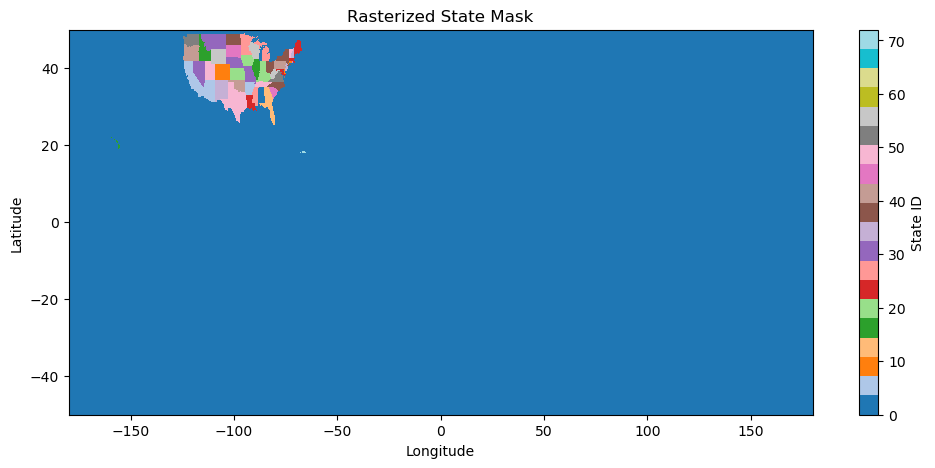

0 00
1 01
<xarray.DataArray 'precip' (time: 3519, y: 400, x: 1440)> Size: 16GB
dask.array<where, shape=(3519, 400, 1440), dtype=float64, chunksize=(1, 400, 1440), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 2kB 49.88 49.62 49.38 ... -49.38 -49.62 -49.88
  * x            (x) float32 6kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time         (time) datetime64[ns] 28kB 1981-01-01 1981-01-02 ... 2019-12-31
    dayofyear    (time) int64 28kB dask.array<chunksize=(1,), meta=np.ndarray>
    spatial_ref  int64 8B 0
<xarray.DataArray 'precip' (time: 3519)> Size: 28kB
dask.array<mean_agg-aggregate, shape=(3519,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 28kB 1981-01-01 1981-01-02 ... 2019-12-31
    dayofyear    (time) int64 28kB dask.array<chunksize=(1,), meta=np.ndarray>
    spatial_ref  int64 8B 0
<xarray.DataArray 'precip' (time: 3519)> Size: 28kB
dask.array<sum-aggregate, shape=(3519,), dtype=float

In [ ]:
df_precip_state = compute_state_precip_anoms_dask(precip_anom_da, 
                                                  states_map, 
                                                  state_col='STATEFP',
                                                  states_mask_file='../data/state_mask_chirps.nc')
df_all.to_csv(outfile, index=False)